# 留年生・退学生の原因分析レポート
このノートブックでは，成績，アンケート，自習アプリ，入学前背景などの多角的なデータを用いて，留年・退学のリスク要因を分析します。

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # 日本語表示用（環境にない場合は pip install japanize-matplotlib）

# グラフのスタイル設定
sns.set(font="IPAexGothic") # または 'MS Gothic' など環境に合わせて調整
plt.rcParams['figure.figsize'] = (12, 6)

# データの読み込み
df = pd.read_csv('20260601_144403_dummy.csv')

# データ型の整理
# Value列は数値に変換可能なものは数値にし，それ以外はNaNにする（成績分析用）
df['Value_num'] = pd.to_numeric(df['Value'], errors='coerce')

print(f"Total rows: {len(df)}")
df.head()

Total rows: 391252


C:\Users\Yusaku\AppData\Local\Temp\ipykernel_26000\3059635633.py:12: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('20260601_144403_dummy.csv')


,ID,Year,Month,Category,Subcategory,Subsubcategory,Value,Value_num
0,6Js5NckD05d1Ltw7GnXkYhkagWqqhR,2022,3,イベント,入学者募集説明会（学外会場）,イベント名,004：入学者募集説明会（学外会場）,NaN
1,3cQ2qPv8uGOpqmBquRkaWPnpsIWl0L,2022,3,イベント,入学者募集説明会（学外会場）,イベント名,004：入学者募集説明会（学外会場）,NaN
2,GSabEeuiDm10kMzfVOrQ7owwmfptmM,2022,3,イベント,入学者募集説明会（学外会場）,イベント名,004：入学者募集説明会（学外会場）,NaN
3,Hf43gRzpzwUYLV6ydIyvKkJ6VO7oFo,2022,3,イベント,入学者募集説明会（学外会場）,イベント名,004：入学者募集説明会（学外会場）,NaN
4,GyYcFLqpV3QFAbNoPHOnXxSbL5k0ey,2022,3,イベント,入学者募集説明会（学外会場）,イベント名,004：入学者募集説明会（学外会場）,NaN


## 1. ターゲット（留年・退学学生）の特定
「去就」カテゴリからターゲット学生を抽出します。

In [39]:
# 留年・退学のラベル付け (2025年度の学生のみを対象とする)
target_events = df[(df['Category'] == '去就') & (df['Year'] == 2025)].copy()
target_ids = target_events['ID'].unique()

# 2025年度のステータスをマスターとして作成
student_status = target_events.sort_values(['Year', 'Month'], ascending=False).drop_duplicates('ID')
student_status = student_status[['ID', 'Value']].rename(columns={'Value': 'Status'})

print(f"2025年度のターゲット学生数: {len(student_status)}")
student_status['Status'].value_counts()

2025年度のターゲット学生数: 80


留年    80
Name: Status, dtype: int64

## 2. 前期中間成績（6月）時点での早期検知分析
6月時点の成績で，後の留年・退学リスクを予見できるか確認します。

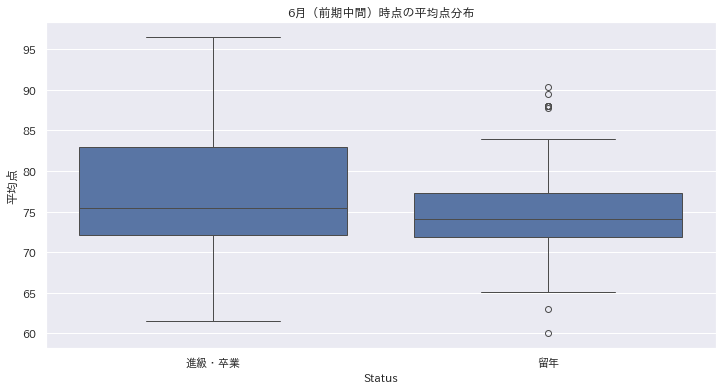

         count       mean       std   min        25%        50%        75%  \
Status                                                                       
留年        74.0  75.296443  6.254817  60.0  71.923077  74.095455  77.333333   
進級・卒業   1336.0  76.873048  6.304051  61.5  72.166667  75.500000  83.000000   

              max  
Status             
留年      90.333333  
進級・卒業   96.500000  


In [40]:
# 6月の成績データを抽出
june_grades = df[(df['Category'] == '成績') & (df['Month'] == 6) & (df['Year'] == 2025)].copy()

# 学生ごとの平均点を算出
june_avg = june_grades.groupby(['ID', 'Year'])['Value_num'].mean().reset_index()

# ステータスをマージ（留年・退学レコードがない学生は '継続' とする）
june_analysis = pd.merge(june_avg, student_status, on='ID', how='left')
june_analysis['Status'] = june_analysis['Status'].fillna('進級・卒業')

# 可視化：ステータス別の6月平均点分布
sns.boxplot(x='Status', y='Value_num', data=june_analysis)
plt.title('6月（前期中間）時点の平均点分布')
plt.ylabel('平均点')
plt.show()

# 統計量表示
print(june_analysis.groupby('Status')['Value_num'].describe())

## 3. 途中からの「失速」分析（月次成績推移）
時期ごとの成績の変化率に注目します。

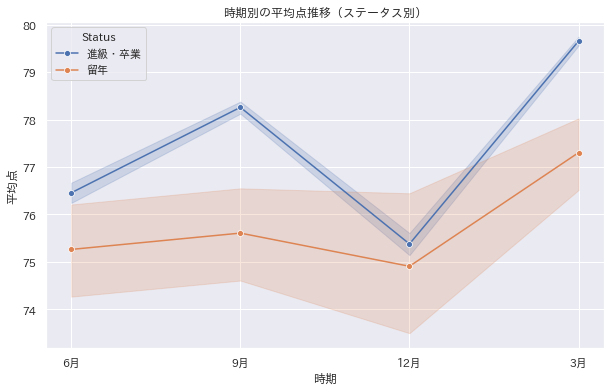

In [41]:
# 月ごとの平均点推移（1年生時を例に）
# 月ごとの平均点推移（1年生時を例に）
monthly_grades = df[df['Category'] == '成績'].groupby(['ID', 'Year', 'Month'])['Value_num'].mean().reset_index()
monthly_grades = pd.merge(monthly_grades, student_status, on='ID', how='left')
monthly_grades['Status'] = monthly_grades['Status'].fillna('進級・卒業')

# 月の順序を強制固定（Categorical型を使用）
month_labels = ['6月', '9月', '12月', '3月']
month_map = {6: '6月', 9: '9月', 12: '12月', 3: '3月'}
monthly_grades['Month_str'] = monthly_grades['Month'].map(month_map)
monthly_grades = monthly_grades.dropna(subset=['Month_str'])

# 順序付きカテゴリカル型に変換することで、グラフ描画時のソート順を固定する
monthly_grades['Month_str'] = pd.Categorical(monthly_grades['Month_str'], categories=month_labels, ordered=True)

# 可視化
plt.figure(figsize=(10, 6))
sns.lineplot(x='Month_str', y='Value_num', hue='Status', data=monthly_grades, marker='o')
plt.title('時期別の平均点推移（ステータス別）')
plt.ylabel('平均点')
plt.xlabel('時期')
plt.show()

## 4. 前年度成績との相関
前年度に「予兆」があったかを確認します。

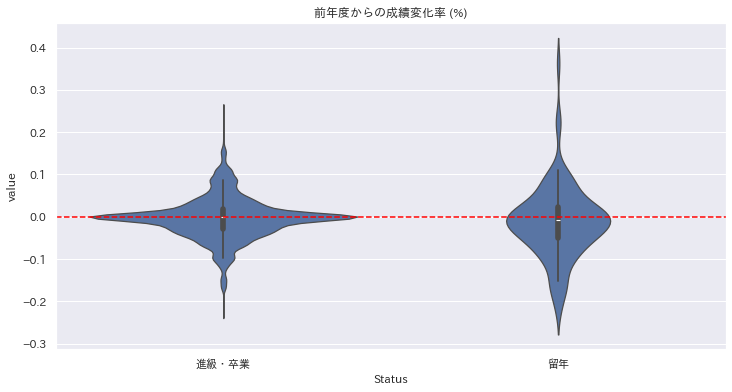

In [42]:
# 年度ごとの通年平均を算出
yearly_avg = df[df['Category'] == '成績'].groupby(['ID', 'Year'])['Value_num'].mean().unstack()

# 留年発生年度の1年前の成績を特定（ここでは簡易的に各学生の年度間差分を分析）
diff_analysis = yearly_avg.pct_change(axis=1).melt(ignore_index=False).reset_index()
diff_analysis = pd.merge(diff_analysis, student_status, on='ID', how='left')
diff_analysis['Status'] = diff_analysis['Status'].fillna('進級・卒業')

sns.violinplot(x='Status', y='value', data=diff_analysis)
plt.title('前年度からの成績変化率 (%)')
plt.axhline(0, color='red', linestyle='--')
plt.show()

## 5. 入学前背景（入試・内申）の影響
中学時代の成績や入試スコアとの関係を見ます。

In [43]:
# 入試・内申データの抽出
entrance_data = df[df['Category'].isin(['学力', '調査書'])].copy()
entrance_pivot = entrance_data.pivot_table(index='ID', columns='Subcategory', values='Value_num', aggfunc='first')

entrance_analysis = pd.merge(entrance_pivot, student_status, on='ID', how='left')
entrance_analysis['Status'] = entrance_analysis['Status'].fillna('進級・卒業')

# 相関が高いと思われる項目の抽出（例：数学，合計点）
cols_to_plot = [c for c in entrance_pivot.columns if '数学' in str(c) or '合計' in str(c)]
if cols_to_plot:
    sns.pairplot(entrance_analysis[cols_to_plot + ['Status']], hue='Status')
    plt.show()

## 6. 科目別リスク分析
どの科目でつまずきやすいか特定します。

In [44]:
# 科目別の平均点をステータス別に比較
subject_grades = df[df['Category'] == '成績'].copy()
subject_avg = subject_grades.groupby(['Subcategory', 'ID'])['Value_num'].mean().reset_index()
subject_analysis = pd.merge(subject_avg, student_status, on='ID', how='left')
subject_analysis['Status'] = subject_analysis['Status'].fillna('進級・卒業')

# ステータス間で平均点の差が大きい科目を抽出
diff_by_sub = subject_analysis.groupby(['Subcategory', 'Status'])['Value_num'].mean().unstack()
diff_by_sub['差分'] = diff_by_sub['進級・卒業'] - diff_by_sub.get('留年', diff_by_sub['進級・卒業'])
top_risk_subs = diff_by_sub.sort_values('差分', ascending=False).head(10)

print("進級・卒業学生と留年生で平均点の差が大きい科目トップ10:")
top_risk_subs

進級・卒業学生と留年生で平均点の差が大きい科目トップ10:


Status,留年,進級・卒業,差分
Subcategory,,,
4CV_語学特講Ⅳ,43.000000,69.555147,26.555147
4EC_オペレーティングシステム,50.333333,75.635897,25.302564
4EC_文学特論Ⅰ,50.000000,73.611111,23.611111
3CV_数学ⅢB,50.000000,72.743386,22.743386
2CV_数学ⅡA,53.541667,74.913420,21.371753
5IT_システム工学,52.666667,72.691358,20.024691
4CN_情報処理Ⅲ,59.250000,79.197917,19.947917
4CV_建設設計製図Ⅰ,59.000000,78.033565,19.033565
4EC_語学特講Ⅲ,63.500000,82.500000,19.000000


## 7. スタディサプリ（自習状況）の予兆
自習アプリの活用度合と成績の相関を確認します。

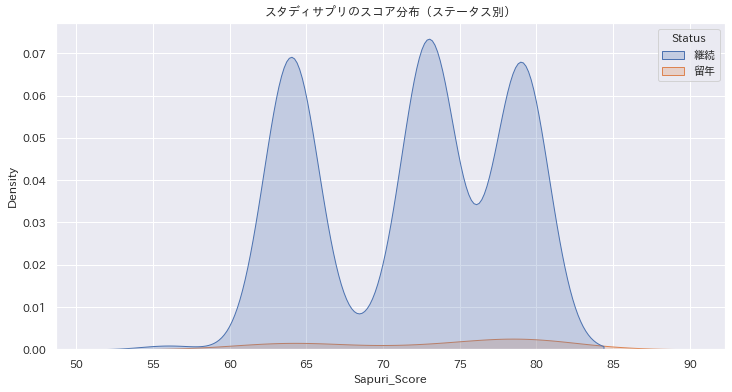

In [45]:
sapuri_data = df[df['Category'] == 'スタディサプリ'].copy()
sapuri_avg = sapuri_data.groupby('ID')['Value_num'].mean().reset_index().rename(columns={'Value_num': 'Sapuri_Score'})

sapuri_analysis = pd.merge(sapuri_avg, student_status, on='ID', how='left')
sapuri_analysis['Status'] = sapuri_analysis['Status'].fillna('継続')

sns.kdeplot(data=sapuri_analysis, x='Sapuri_Score', hue='Status', fill=True)
plt.title('スタディサプリのスコア分布（ステータス別）')
plt.show()

## 8. PDFレポートの出力
これまでの分析結果（グラフ，使用データ，説明）をPDFファイルとして保存します。

In [46]:
from matplotlib.backends.backend_pdf import PdfPages
import textwrap
from scipy import stats

def add_page_with_text(pdf, title, description, stats_df=None, p_value=None):
    """PDFにテキスト説明ページを追加する補助関数（折り返し対応・有意差対応）"""
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.axis('off')
    plt.text(0.5, 0.95, title, fontsize=20, weight='bold', ha='center')
    
    # 説明書きの表示 (textwrapで折り返し)
    plt.text(0.05, 0.88, "【分析の説明】", fontsize=14, weight='bold', ha='left')
    wrapped_desc = textwrap.fill(description, width=40)  # 幅40文字で折り返し
    plt.text(0.05, 0.85, wrapped_desc, fontsize=12, ha='left', va='top')
    
    # 有意差分析（p値）の表示
    if p_value is not None:
        plt.text(0.05, 0.65, "【統計的有意差検定 (t-検定)】", fontsize=14, weight='bold', ha='left')
        sig_text = f"p値 = {p_value:.4f} "
        if p_value < 0.05:
            sig_text += "(有意差あり: p < 0.05)"
        else:
            sig_text += "(有意差なし: p >= 0.05)"
        plt.text(0.05, 0.60, sig_text, fontsize=12, weight='bold', color='red' if p_value < 0.05 else 'black', ha='left')
    
    # 統計データの表示
    if stats_df is not None:
        plt.text(0.05, 0.50, "【主要な統計データ】", fontsize=14, weight='bold', ha='left')
        stats_str = stats_df.to_string()
        plt.text(0.05, 0.45, stats_str, fontsize=10, family='monospace', ha='left', va='top')
    
    pdf.savefig(fig)
    plt.close()

def calculate_p_value(df, group_col, value_col):
    """2群間のt検定を行う"""
    groups = df[group_col].dropna().unique()
    if len(groups) < 2: return None
    g1_data = df[df[group_col] == groups[0]][value_col].dropna()
    g2_data = df[df[group_col] == groups[1]][value_col].dropna()
    if len(g1_data) < 2 or len(g2_data) < 2: return None
    # ウェルチのt検定
    t_stat, p_val = stats.ttest_ind(g1_data, g2_data, equal_var=False)
    return p_val

def export_analysis_to_pdf(filename='Detailed_Analysis_Report_v2.pdf'):
    with PdfPages(filename) as pdf:
        # --- 表紙 ---
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.axis('off')
        plt.text(0.5, 0.6, '2025年度 留年生・退学生原因分析レポート', fontsize=24, weight='bold', ha='center')
        plt.text(0.5, 0.4, f'出力日: {pd.Timestamp.now().strftime("%Y/%m/%d")}', fontsize=14, ha='center')
        pdf.savefig(fig)
        plt.close()

        # --- 1. 6月成績分布 ---
        desc1 = "前期中間（6月）時点での成績分布です。留年・退学に至る学生は，この時点で既に平均点が低い傾向にあり，早期の学習支援が重要であることを示唆しています。"
        stats1 = june_analysis.groupby('Status')['Value_num'].describe().round(2)
        p1 = calculate_p_value(june_analysis, 'Status', 'Value_num')
        add_page_with_text(pdf, "1. 前期中間成績による早期検知", desc1, stats1, p1)
        
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Status', y='Value_num', data=june_analysis)
        plt.title('6月（前期中間）時点の平均点分布')
        pdf.savefig()
        plt.close()

        # --- 2. 成績推移 ---
        desc2 = "年度内の成績推移です。特定の時期（例：夏休み明けの9月や後期）に急激に成績が低下する学生を特定することで，介入のタイミングを計ることができます。"
        stats2 = monthly_grades.groupby(['Status', 'Month'])['Value_num'].mean().unstack().round(2)
        add_page_with_text(pdf, "2. 時期別の成績推移", desc2, stats2)
        
        plt.figure(figsize=(10, 6))
        sns.lineplot(x='Month', y='Value_num', hue='Status', data=monthly_grades, marker='o')
        plt.title('時期別の平均点推移')
        plt.xticks([6, 9, 12, 3])
        pdf.savefig()
        plt.close()

        # --- 3. 成績変化率 ---
        desc3 = "前年度の学年末成績と比較した，本年度の成績変化率です。マイナス幅が大きい学生は，前年度までは問題なかったものの，本年度の環境変化に適応できていない可能性があります。"
        stats3 = diff_analysis.groupby('Status')['value'].describe().round(4)
        p3 = calculate_p_value(diff_analysis, 'Status', 'value')
        add_page_with_text(pdf, "3. 前年度からの成績変化率", desc3, stats3, p3)
        
        plt.figure(figsize=(10, 6))
        sns.violinplot(x='Status', y='value', data=diff_analysis)
        plt.title('前年度からの成績変化率 (%)')
        plt.axhline(0, color='red', linestyle='--')
        pdf.savefig()
        plt.close()

        # --- 4. スタディサプリ ---
        desc4 = "自習アプリ（スタディサプリ）の活用度合いです。自習習慣の欠如が成績不振の根本原因となっているケースを特定します。"
        stats4 = sapuri_analysis.groupby('Status')['Sapuri_Score'].describe().round(2)
        p4 = calculate_p_value(sapuri_analysis, 'Status', 'Sapuri_Score')
        add_page_with_text(pdf, "4. 自習アプリのスコア分布", desc4, stats4, p4)
        
        plt.figure(figsize=(10, 6))
        sns.kdeplot(data=sapuri_analysis, x='Sapuri_Score', hue='Status', fill=True)
        plt.title('スタディサプリのスコア分布')
        pdf.savefig()
        plt.close()

    print(f"詳細レポート(v2)を {filename} として出力しました。")

export_analysis_to_pdf()

C:\Users\Yusaku\AppData\Local\Temp\ipykernel_26000\1118684586.py:32: UserWarning: Glyph 30041 (\N{CJK UNIFIED IDEOGRAPH-7559}) missing from font(s) DejaVu Sans Mono.
  pdf.savefig(fig)
C:\Users\Yusaku\AppData\Local\Temp\ipykernel_26000\1118684586.py:32: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans Mono.
  pdf.savefig(fig)
C:\Users\Yusaku\AppData\Local\Temp\ipykernel_26000\1118684586.py:32: UserWarning: Glyph 36914 (\N{CJK UNIFIED IDEOGRAPH-9032}) missing from font(s) DejaVu Sans Mono.
  pdf.savefig(fig)
C:\Users\Yusaku\AppData\Local\Temp\ipykernel_26000\1118684586.py:32: UserWarning: Glyph 32026 (\N{CJK UNIFIED IDEOGRAPH-7D1A}) missing from font(s) DejaVu Sans Mono.
  pdf.savefig(fig)
C:\Users\Yusaku\AppData\Local\Temp\ipykernel_26000\1118684586.py:32: UserWarning: Glyph 12539 (\N{KATAKANA MIDDLE DOT}) missing from font(s) DejaVu Sans Mono.
  pdf.savefig(fig)
C:\Users\Yusaku\AppData\Local\Temp\ipykernel_26000\1118684586.py:32: UserWarning: 

詳細レポート(v2)を Detailed_Analysis_Report_v2.pdf として出力しました。


## まとめ
以上の分析から，どの指標が最も留年・退学の早期検知に有効かを特定し，フォローアップ体制の構築に役立てます。